# Mental Health Chatbot Fine-tuning with ShenLab/MentalChat16K

This notebook fine-tunes Qwen2.5-0.5B-Instruct using LoRA on ShenLab/MentalChat16K dataset.

**Dataset**: ShenLab/MentalChat16K - 16K mental health counseling conversations
**Model**: Qwen2.5-0.5B-Instruct
**Method**: LoRA (Low-Rank Adaptation)

In [1]:
!pip install transformers peft trl datasets evaluate sacrebleu rouge-score nltk torch accelerate scikit-learn matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 14.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, set_seed
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset, load_dataset
from trl import SFTTrainer
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import evaluate

In [3]:
print("=" * 50)
print("Environment Setup")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Environment Setup
PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda


---
## Step 0: Setup & Configuration

In [4]:
DATASET_SIZE = 5000
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
OUTPUT_DIR = "./mentalchat_output"
SEED = 42

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

print(f"Dataset size: {DATASET_SIZE}")
print(f"Train/Val/Test: {int(DATASET_SIZE*TRAIN_RATIO)}/{int(DATASET_SIZE*VAL_RATIO)}/{int(DATASET_SIZE*TEST_RATIO)}")

Dataset size: 5000
Train/Val/Test: 4000/500/500


---
## Step 1: Load & Describe Data

### 1.1 Load Dataset

In [5]:
print("Loading dataset from Hugging Face...")
ds = load_dataset("ShenLab/MentalChat16K")
df = ds['train'].to_pandas()
print(f"Original dataset size: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

df = df.sample(n=DATASET_SIZE, random_state=SEED).reset_index(drop=True)
print(f"Using dataset size: {len(df)}")
df.head(3)

Loading dataset from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

Interview_Data_6K.csv:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Synthetic_Data_10K.csv:   0%|          | 0.00/32.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16084 [00:00<?, ? examples/s]

Original dataset size: 16084
Columns: ['instruction', 'input', 'output']
Using dataset size: 5000


,instruction,input,output
0,You are a helpful mental health counselling as...,I've been waking up early to help my mom with ...,I can see how challenging this situation is fo...
1,You are a helpful mental health counselling as...,I've been wrestling with the dilemma of whethe...,"Your mom's situation is complex, and it's unde..."
2,You are a helpful mental health counselling as...,I'm worried about my husband's health and our ...,I can see how your husband's health issues and...


### 1.2 EDA - Exploratory Data Analysis

In [6]:
df['input_len'] = df['input'].apply(lambda x: len(str(x).split()))
df['output_len'] = df['output'].apply(lambda x: len(str(x).split()))

print("=== Thống kê độ dài (words) ===")
print(df[['input_len', 'output_len']].describe())

=== Thống kê độ dài (words) ===
         input_len   output_len
count  5000.000000  5000.000000
mean     94.625200   314.198000
std      85.437326   125.818285
min       1.000000    35.000000
25%      50.000000   251.000000
50%      66.000000   329.000000
75%      99.000000   383.000000
max    2664.000000  1456.000000


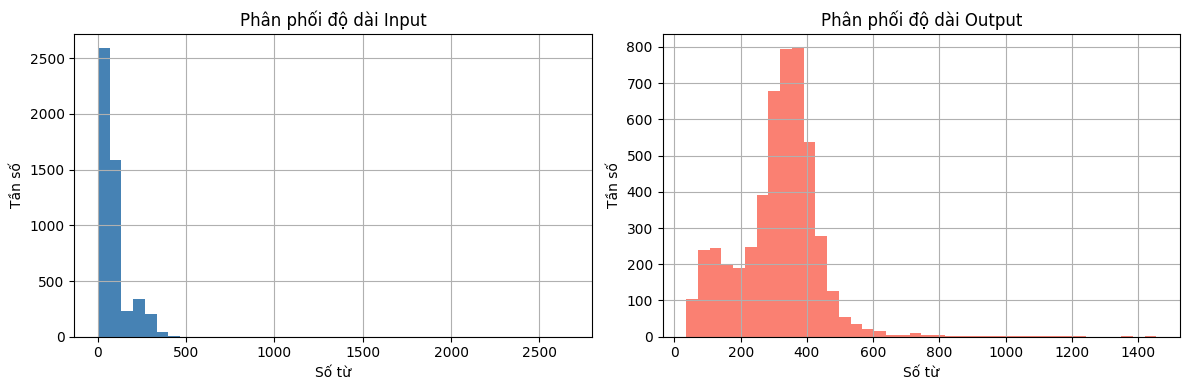

SAMPLE DATA EXAMPLES

--- Example 1 ---
[INPUT]:  I've been waking up early to help my mom with her morning routine, then heading to the hospital to visit her for a few hours before coming home to cook dinner and take care of household chores. I've b...
[OUTPUT]: I can see how challenging this situation is for you, and it's essential to address the guilt and anxiety you're experiencing. It's crucial to recognize that taking care of yourself is not a selfish ac...
--------------------------------------------------------------------------------

--- Example 2 ---
[INPUT]:  I've been wrestling with the dilemma of whether to keep my 85-year-old mom at home or send her to a nursing home. This internal conflict has been consuming my thoughts for months, and it seems to inte...
[OUTPUT]: Your mom's situation is complex, and it's understandable that you're grappling with this decision. Based on our previous discussions, we've created a pro-con list comparing home care and nursing home ...
----

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['input_len'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("Phân phối độ dài Input")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Tần số")

df['output_len'].hist(bins=40, ax=axes[1], color='salmon')
axes[1].set_title("Phân phối độ dài Output")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Tần số")

plt.tight_layout()
plt.savefig("eda_length_distribution.png", dpi=150)
plt.show()

# Hiển thị một số ví dụ mẫu từ dataset
print("=" * 80)
print("SAMPLE DATA EXAMPLES")
print("=" * 80)

for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"[INPUT]:  {df.iloc[i]['input'][:200]}...")
    print(f"[OUTPUT]: {df.iloc[i]['output'][:200]}...")
    print("-" * 80)

### 1.3 Train/Val/Test Split

In [8]:
train_df, temp_df = train_test_split(df, test_size=(VAL_RATIO + TEST_RATIO), random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 4000 | Val: 500 | Test: 500


---
## Step 2: Format Data

In [9]:
SYSTEM_PROMPT = (
    "You are a compassionate and professional mental health counsellor. "
    "Provide empathetic, helpful, and accurate responses to users seeking emotional support."
)

def format_conversation(example):
    instruction = str(example.get('instruction', SYSTEM_PROMPT))
    user_input = str(example.get('input', ''))
    response = str(example.get('output', ''))
    return {
        'text': (
            f"<|im_start|>system\n{instruction}<|im_end|>\n"
            f"<|im_start|>user\n{user_input.strip()}<|im_end|>\n"
            f"<|im_start|>assistant\n{response.strip()}<|im_end|>"
        )
    }

train_dataset = Dataset.from_list(train_df.apply(format_conversation, axis=1).tolist())
val_dataset = Dataset.from_list(val_df.apply(format_conversation, axis=1).tolist())
test_dataset = Dataset.from_list(test_df.apply(format_conversation, axis=1).tolist())

print(f"Sample formatted text:\n{train_dataset[0]['text'][:300]}")

Sample formatted text:
<|im_start|>system
You are a helpful mental health counselling assistant, please answer the mental health questions based on the patient's description. 
The assistant gives helpful, comprehensive, and appropriate answers to the user's questions. <|im_end|>
<|im_start|>user
I've been feeling this way


---
## Step 3: Load Model & Tokenizer

### Decoder Transformer Architecture

The model uses a Decoder-only Transformer architecture:
- **Self-Attention**: Each token attends to all previous tokens in the sequence
- **Causal Masking**: Ensures that predictions can only depend on previous tokens
- **Layer Normalization & Residual Connections**: Stabilize training
- **Feed-Forward Networks**: Two linear transformations with GELU activation

In [10]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False
print(f"Device: {device} | Parameters: {model.num_parameters():,}")

Loading tokenizer...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading model...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Device: cuda | Parameters: 494,032,768


---
## Step 4: Configure LoRA

### LoRA Explanation

**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning method that:

- **r (rank)**: The rank of the low-rank matrices. Higher r = more parameters to learn, better capacity. We use r=16 for 3000 samples.

- **lora_alpha**: Scaling factor. Usually set to 2×r = 32. Controls the magnitude of LoRA updates.

- **target_modules**: Which layers to adapt:
  - `q_proj, k_proj, v_proj, o_proj`: Attention projection matrices
  - `gate_proj, up_proj, down_proj`: Feed-forward network matrices

- **lora_dropout**: Dropout probability for LoRA layers (0.05)

In [11]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                   "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


---
## Step 5: Training with Validation

In [12]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    remove_unused_columns=False,
)

print("Training arguments configured")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments configured


In [13]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    formatting_func=lambda x: x['text'],
)

print("Trainer initialized")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Applying formatting function to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Applying formatting function to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Trainer initialized


In [14]:
print("=" * 50)
print("Starting training...")
print("=" * 50)

train_result = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting training...


Step,Training Loss,Validation Loss
100,1.214583,1.185523
200,1.148373,1.132460
300,1.050701,1.108686
400,1.032866,1.089580
500,1.039678,1.075785
600,0.965432,1.075505
700,0.965095,1.072471


In [15]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Model saved to ./mentalchat_output


### 5.1 Plot Training & Validation Loss Curve

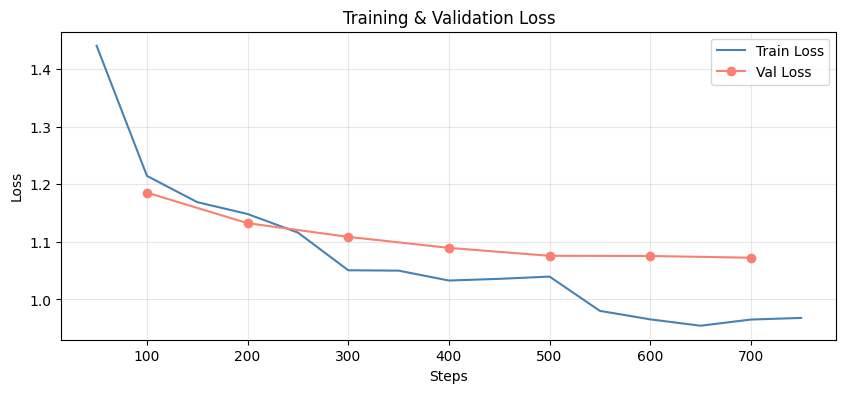

In [16]:
log_history = trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
val_steps = [x['step'] for x in log_history if 'eval_loss' in x]
val_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label="Train Loss", color="steelblue")
plt.plot(val_steps, val_losses, label="Val Loss", color="salmon", marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Model Evaluation

### 6.1 Load Fine-tuned Model

In [17]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load tokenizer và base model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # QUAN TRỌNG: padding bên trái cho batched generation

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True
)

# Load LoRA weights từ file đã lưu
model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model.eval()
print(f"✅ Model loaded from {OUTPUT_DIR}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✅ Model loaded from ./mentalchat_output


### 6.2 Batch Generation + ROUGE Evaluation

In [18]:
import evaluate
from tqdm import tqdm

BATCH_SIZE = 8
MAX_NEW_TOKENS = 256

tokenizer.padding_side = "left"  # Left padding is required for stable batched generation with decoder-only models.
model.eval()

def batch_generate(inputs_list, batch_size=BATCH_SIZE):
    all_responses = []

    for i in tqdm(range(0, len(inputs_list), batch_size), desc="Evaluating"):
        batch_texts = inputs_list[i : i + batch_size]

        batch_prompts = []
        for user_input in batch_texts:
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_input},
            ]
            prompt = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            batch_prompts.append(prompt)

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Generation always starts after the padded input length for each row in this batch.
        padded_input_len = inputs["input_ids"].shape[1]
        for output in outputs:
            decoded = tokenizer.decode(output[padded_input_len:], skip_special_tokens=True)
            all_responses.append(decoded.strip())

    return all_responses

# --- Run evaluation ---
inputs_list = test_df["input"].astype(str).tolist()
references = test_df["output"].astype(str).tolist()
predictions = batch_generate(inputs_list, batch_size=BATCH_SIZE)

rouge_metric = evaluate.load("rouge")
rouge_results = rouge_metric.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
)
print("\n--- ROUGE Scores ---")
for k, v in rouge_results.items():
    print(f"  {k}: {v:.4f}")

Evaluating: 100%|██████████| 63/63 [18:09<00:00, 17.29s/it]



--- ROUGE Scores ---
  rouge1: 0.4682
  rouge2: 0.1411
  rougeL: 0.2023
  rougeLsum: 0.3634


### 6.3 BERTScore (Semantic Similarity)

In [19]:
!pip install bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00


In [20]:
from bert_score import score as bert_score_fn

if "predictions" not in globals() or "references" not in globals():
    inputs_list = test_df["input"].astype(str).tolist()
    references = test_df["output"].astype(str).tolist()
    predictions = batch_generate(inputs_list, batch_size=BATCH_SIZE)

P, R, F1 = bert_score_fn(
    predictions,
    references,
    lang="en",
    model_type="distilbert-base-uncased",
    verbose=True,
)

avg_precision = P.mean().item()
avg_recall = R.mean().item()
avg_f1 = F1.mean().item()

print("\n=== BERTScore ===")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall   : {avg_recall:.4f}")
print(f"  F1       : {avg_f1:.4f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/16 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/8 [00:00<?, ?it/s]

done in 12.71 seconds, 39.34 sentences/sec

=== BERTScore ===
  Precision: 0.8326
  Recall   : 0.8210
  F1       : 0.8265


### 6.4 Summary Results Table

In [21]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum", "BERTScore F1"],
    "Score": [
        rouge_results["rouge1"],
        rouge_results["rouge2"],
        rouge_results["rougeL"],
        rouge_results["rougeLsum"],
        avg_f1,
    ],
})
print(results_df.to_string(index=False))
results_df.to_csv("evaluation_results.csv", index=False)
print("\nResults saved to evaluation_results.csv")

      Metric    Score
     ROUGE-1 0.468151
     ROUGE-2 0.141108
     ROUGE-L 0.202331
  ROUGE-Lsum 0.363371
BERTScore F1 0.826518

Results saved to evaluation_results.csv


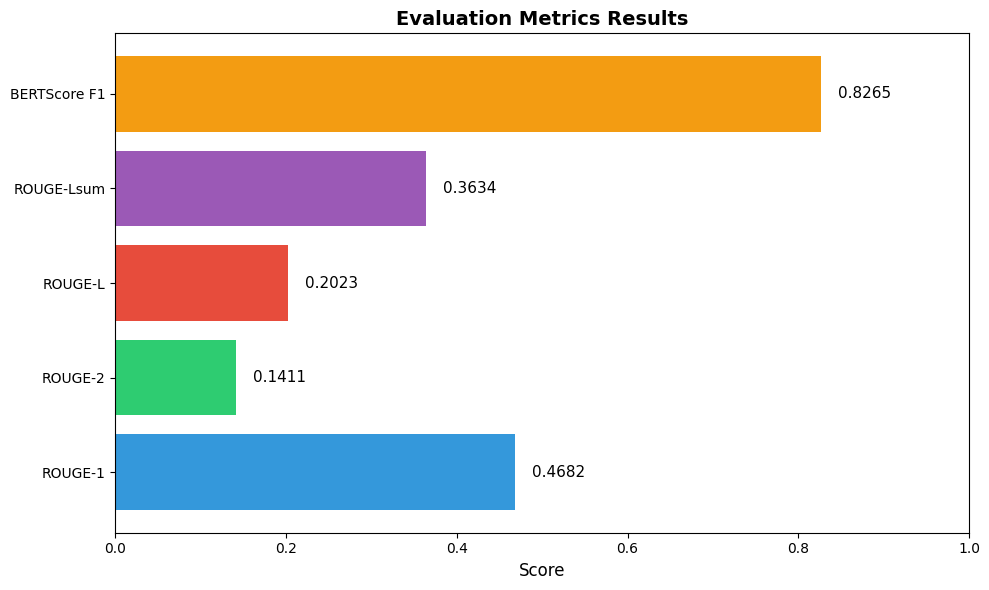

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum', 'BERTScore F1']
scores = [rouge_results["rouge1"], rouge_results["rouge2"], 
          rouge_results["rougeL"], rouge_results["rougeLsum"], avg_f1]

# Tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = ax.barh(metrics, scores, color=colors)

ax.set_xlabel('Score', fontsize=12)
ax.set_title('Evaluation Metrics Results', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)

# Thêm giá trị trên mỗi cột
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('evaluation_metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Qualitative Analysis

In [23]:
print("=== Qualitative Analysis (from evaluated predictions) ===\n")

if "predictions" not in globals() or "references" not in globals():
    inputs_list = test_df["input"].astype(str).tolist()
    references = test_df["output"].astype(str).tolist()
    predictions = batch_generate(inputs_list, batch_size=BATCH_SIZE)

if "rouge_metric" not in globals():
    import evaluate
    rouge_metric = evaluate.load("rouge")

sample_indices = [0, 50, 100, 150, 200]
sample_indices = [i for i in sample_indices if i < len(predictions)]

for i in sample_indices:
    input_text = str(test_df.iloc[i]["input"])
    ref_text = references[i]
    pred_text = predictions[i]

    sample_rouge_l = rouge_metric.compute(
        predictions=[pred_text],
        references=[ref_text],
        use_stemmer=True,
    )["rougeL"]

    print(f"[Example {i + 1}]  ROUGE-L: {sample_rouge_l:.4f}")
    print(f"INPUT       : {input_text[:150]}...")
    print(f"GROUND TRUTH: {ref_text[:200]}...")
    print(f"PREDICTED   : {pred_text[:200]}...")
    print("-" * 70)

=== Qualitative Analysis (from evaluated predictions) ===

[Example 1]  ROUGE-L: 0.2488
INPUT       : I've been feeling overwhelmed and powerless since my husband's diagnosis with Parkinson's disease. Watching him struggle with daily tasks and seeing h...
GROUND TRUTH: Your feelings of helplessness and frustration are valid, given the challenging circumstances you and your husband are facing. It's important to remember that caregiving for a loved one with a chronic ...
PREDICTED   : Your feelings of frustration and helplessness are understandable given the circumstances. It's essential to recognize that your husband's condition is complex, and there isn't a one-size-fits-all solu...
----------------------------------------------------------------------
[Example 51]  ROUGE-L: 0.2018
INPUT       : I've been taking care of my wife for years now, ever since she had a stroke that left her unable to walk. The thought of her being in pain and discomf...
GROUND TRUTH: I can only imagine how ch

---
## Summary

Final metrics are shown in the `results_df` table above and saved to `evaluation_results.csv`.

**Training completed successfully!**
- Model saved to: `{OUTPUT_DIR}`
- Loss curves saved: `loss_curve.png`
- Evaluation results: `evaluation_results.csv`